# 🛰️ CubeSat EPS — Estimation du SOH avec LSTM

**Stratégie** : le modèle LSTM prédit `delta_SOH` (variation cycle-à-cycle du SOH).
Le SOH est ensuite **reconstruit** en ajoutant la prédiction au dernier SOH connu de chaque fenêtre.

**Prérequis :** `train_normalized.csv` et `test_normalized.csv` disponibles dans Google Drive.

---

| # | Section | Description |
|---|---------|-------------|
| 1 | Imports | Librairies |
| 2 | Chargement | Drive + CSV |
| 3 | Feature engineering | Calcul `delta_SOH` + normalisation |
| 4 | Paramètres | Fenêtre, horizon, etc. |
| 5 | Inspection | Aperçu des données |
| 6 | Séquences | Sliding window |
| 7 | Modèle LSTM | Architecture |
| 8 | Entraînement | Fit + callbacks |
| 9 | Reconstruction SOH | Inverse-transform + cumsum |
| 10 | Évaluation | Métriques sur le SOH reconstruit |
| 11 | Visualisations | Courbes, scatter, résidus |
| 12 | Sauvegarde | Modèle + artefacts |

## 1 — Imports

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    r2_score, explained_variance_score, max_error
)

print(f'TensorFlow : {tf.__version__}')
print(f'GPU        : {tf.config.list_physical_devices("GPU")}')

TensorFlow : 2.20.0
GPU        : []


## 2 — Chargement des données

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = '/content/drive/MyDrive/Colab Notebooks/dataset'

train_df = pd.read_csv(os.path.join(DATA_DIR, 'train_normalized.csv'))
test_df  = pd.read_csv(os.path.join(DATA_DIR, 'test_normalized.csv'))

print(f'Train shape : {train_df.shape}')
print(f'Test  shape : {test_df.shape}')
train_df.head()

Mounted at /content/drive
Train shape : (5445, 22)
Test  shape : (1362, 22)


,cycle,V_mean_V,V_spread,V_mean_rolling,V_mean_lag_1,V_min_fade,Tavg_C,thermal_range,delta_T_ambient,cold_cycle_count,...,QD_Ah,coulombic_eff,discharge_C_rate,capacity_retention,QD_rolling,cycle.1,cumul_Ah,SOH_lag_1,QD_diff,SOH
0,2,1.750565,-0.992064,1.756331,1.689071,2.139280,0.817626,-0.920884,-1.089614,-1.731733,...,1.742836,-2.220446e-16,1.253060,1.742836,1.740326,2,-1.812547,1.743112,-2.353289,0.999884
1,3,1.803118,-0.568419,1.784584,1.749768,1.957647,-0.868273,0.998808,1.060383,-1.731097,...,1.741958,-2.220446e-16,2.004439,1.741958,1.739877,3,-1.811822,1.742171,-1.878584,0.999822
2,4,1.957786,-1.191684,1.838243,1.802311,2.424008,0.951343,-1.034030,-1.010917,-1.730460,...,1.741016,1.554312e-15,2.126213,1.741016,1.739417,4,-1.811096,1.741293,-2.362861,0.999756
3,5,1.793527,-0.469706,1.836851,1.956952,1.897934,-1.021337,1.044310,0.970300,-1.729824,...,1.740114,8.881784e-16,1.545265,1.740114,1.738960,5,-1.810371,1.740351,-2.059840,0.999692
4,6,1.911636,-1.076249,1.856049,1.792722,2.339811,0.945306,-0.994530,-1.014470,-1.729188,...,1.739159,-4.440892e-16,1.840414,1.739159,1.738497,6,-1.809645,1.739449,-2.454243,0.999625


## 3 — Feature Engineering

On calcule `delta_SOH = SOH[t] - SOH[t-1]` comme **cible** du modèle.
On conserve également `soh_raw` (valeurs non-normalisées de SOH dans l'espace des features)
pour la reconstruction finale.

> **Important** : `scaler_y` est ajusté **uniquement** sur le train et appliqué au test
> afin d'éviter tout data-leakage.

In [ ]:
# ── 3.1  Calcul de delta_SOH ─────────────────────────────────────────────────
train_df['delta_SOH'] = train_df['SOH'].diff()
test_df['delta_SOH']  = test_df['SOH'].diff()

# Supprimer la première ligne (NaN issu du diff)
train_df = train_df.dropna(subset=['delta_SOH']).reset_index(drop=True)
test_df  = test_df.dropna(subset=['delta_SOH']).reset_index(drop=True)

# ── 3.2  Normalisation de la cible delta_SOH (fit sur train uniquement) ───────
scaler_y = StandardScaler()
train_df['delta_SOH_scaled'] = scaler_y.fit_transform(train_df[['delta_SOH']])
test_df['delta_SOH_scaled']  = scaler_y.transform(test_df[['delta_SOH']])

print('delta_SOH stats (train):')
print(train_df['delta_SOH'].describe().to_string())
print(f'\nscaler_y  mean={scaler_y.mean_[0]:.6f}  std={scaler_y.scale_[0]:.6f}')

delta_SOH stats (train):
count    5444.000000
mean       -0.000044
std         0.000009
min        -0.000068
25%        -0.000051
50%        -0.000042
75%        -0.000036
max        -0.000029

scaler_y  mean=-0.000044  std=0.000009


## 4 — Paramètres

In [ ]:
OUTPUT_DIR  = 'outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Colonne cible (espace normalisé → sera inversée après prédiction)
TARGET_COL = 'delta_SOH_scaled'

# Sliding window
WINDOW_SIZE = 20   # cycles de contexte
STEP_SIZE   = 3   # pas du sliding window
HORIZON     = 100    # prédire delta_SOH à t+1

overlap = (WINDOW_SIZE - STEP_SIZE) / WINDOW_SIZE * 100
print(f'WINDOW_SIZE = {WINDOW_SIZE}  |  STEP_SIZE = {STEP_SIZE}  |  HORIZON = {HORIZON}')
print(f'Overlap     = {overlap:.1f} %')
print('Paramètres chargés ✅')

WINDOW_SIZE = 20  |  STEP_SIZE = 3  |  HORIZON = 100
Overlap     = 85.0 %
Paramètres chargés ✅


## 5 — Inspection des données

In [ ]:
# Colonnes features = tout sauf les colonnes cible/auxiliaires
EXCLUDE_COLS  = ['SOH', 'delta_SOH', 'delta_SOH_scaled']
FEATURE_COLS  = [c for c in train_df.columns if c not in EXCLUDE_COLS]

print(f'Train : {train_df.shape}  |  Test : {test_df.shape}')
print(f'\nFeatures ({len(FEATURE_COLS)}) :')
print(FEATURE_COLS)
print(f'\nCible (espace normalisé) : {TARGET_COL}')

# Vérification : pas de NaN dans les features
assert train_df[FEATURE_COLS].isna().sum().sum() == 0, 'NaN dans features train !'
assert test_df[FEATURE_COLS].isna().sum().sum()  == 0, 'NaN dans features test  !'
print('\n✅ Aucun NaN détecté dans les features')

Train : (5444, 24)  |  Test : (1361, 24)

Features (21) :
['cycle', 'V_mean_V', 'V_spread', 'V_mean_rolling', 'V_mean_lag_1', 'V_min_fade', 'Tavg_C', 'thermal_range', 'delta_T_ambient', 'cold_cycle_count', 'Tavg_rolling', 'eclipse_flag', 'QD_Ah', 'coulombic_eff', 'discharge_C_rate', 'capacity_retention', 'QD_rolling', 'cycle.1', 'cumul_Ah', 'SOH_lag_1', 'QD_diff']

Cible (espace normalisé) : delta_SOH_scaled

✅ Aucun NaN détecté dans les features


## 6 — Construction des séquences (Sliding Window)

La fonction retourne également `last_soh` : le SOH **non-normalisé** du dernier
cycle de chaque fenêtre — nécessaire pour reconstruire SOH = last_soh + Δ_pred.

In [ ]:
def build_sequences(df, window, step, horizon, feature_cols, target_col):
    """
    Construit les séquences (X, y) par sliding window.

    Retourne
    --------
    X          : (N, window, n_features)  float32
    y_scaled   : (N,)  delta_SOH normalisé  float32
    last_soh   : (N,)  SOH brut du dernier cycle de la fenêtre  float64
    true_soh   : (N,)  SOH brut cible (cycle window+horizon-1)  float64
    """
    features  = df[feature_cols].values
    target    = df[target_col].values          # delta_SOH normalisé
    soh_raw   = df['SOH'].values               # SOH original (espace normalisé features)
    n_total   = len(df)
    max_start = n_total - window - horizon + 1

    if max_start <= 0:
        raise ValueError(
            f'Pas assez de données ({n_total} lignes) '
            f'pour window={window} + horizon={horizon}.'
        )

    X_list, y_list, last_soh_list, true_soh_list = [], [], [], []

    for start in range(0, max_start, step):
        end  = start + window                  # index exclusif de la fenêtre
        pred = end + horizon - 1               # index de la cible

        X_list.append(features[start:end])     # fenêtre de features
        y_list.append(target[pred])            # delta_SOH normalisé cible
        last_soh_list.append(soh_raw[end - 1]) # dernier SOH connu de la fenêtre
        true_soh_list.append(soh_raw[pred])    # SOH réel à prédire

    X        = np.array(X_list,        dtype=np.float32)
    y_scaled = np.array(y_list,        dtype=np.float32)
    last_soh = np.array(last_soh_list, dtype=np.float64)
    true_soh = np.array(true_soh_list, dtype=np.float64)

    print(f'  {n_total:,} lignes → {len(X_list):,} séquences  |  X={X.shape}')
    return X, y_scaled, last_soh, true_soh


print('[Train]')
X_train, y_train_scaled, last_soh_train, true_soh_train = build_sequences(
    train_df, WINDOW_SIZE, STEP_SIZE, HORIZON, FEATURE_COLS, TARGET_COL
)

print('[Test]')
X_test, y_test_scaled, last_soh_test, true_soh_test = build_sequences(
    test_df, WINDOW_SIZE, STEP_SIZE, HORIZON, FEATURE_COLS, TARGET_COL
)

# Sanity checks
assert not np.any(np.isnan(X_train)),         'NaN dans X_train !'
assert not np.any(np.isnan(X_test)),          'NaN dans X_test  !'
assert not np.any(np.isnan(y_train_scaled)),  'NaN dans y_train_scaled !'
assert not np.any(np.isnan(y_test_scaled)),   'NaN dans y_test_scaled  !'

print(f'\ndelta_SOH_scaled train — min={y_train_scaled.min():.3f}  max={y_train_scaled.max():.3f}')
print(f'delta_SOH_scaled test  — min={y_test_scaled.min():.3f}  max={y_test_scaled.max():.3f}')
print(f'\nSOH réel train         — min={true_soh_train.min():.4f}  max={true_soh_train.max():.4f}')
print(f'SOH réel test          — min={true_soh_test.min():.4f}  max={true_soh_test.max():.4f}')
print('\n✅ Séquences prêtes')

[Train]
  5,444 lignes → 1,775 séquences  |  X=(1775, 20, 21)
[Test]
  1,361 lignes → 414 séquences  |  X=(414, 20, 21)

delta_SOH_scaled train — min=-2.557  max=1.616
delta_SOH_scaled test  — min=-1.812  max=1.235

SOH réel train         — min=0.7589  max=0.9933
SOH réel test          — min=0.7001  max=0.7531

✅ Séquences prêtes


## 7 — Architecture du modèle LSTM

In [ ]:
def build_lstm_model(window_size, n_features, lr=1e-3, l2_reg=1e-4):
    model = Sequential([
        LSTM(32,
             return_sequences=True,
             kernel_regularizer=None,
             input_shape=(window_size, n_features)),
        BatchNormalization(),

        LSTM(16,
             return_sequences=False,
             kernel_regularizer=l2(l2_reg)),
        BatchNormalization(),

        Dense(16, activation='relu', kernel_regularizer=l2(l2_reg)),
        Dropout(0.3),

        Dense(1, activation='linear', name='delta_SOH_output')
    ], name='LSTM_SOH_Estimator')

    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-3),
        loss='mse',
        metrics=['mae']
    )
    return model


model = build_lstm_model(X_train.shape[1], X_train.shape[2])
model.summary()

Model: "LSTM_SOH_Estimator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_22 (LSTM)                  │ (None, 20, 32)         │         6,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 20, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_23 (LSTM)                  │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ delta_SOH_output (Dense)        │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,529 (41.13 KB)

 Trainable params: 10,433 (40.75 KB)

 Non-trainable params: 96 (384.00 B)

## 8 — Entraînement

In [ ]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=10,
        min_lr=1e-6,
        verbose=1
    ),
]

history = model.fit(
    X_train, y_train_scaled,
    validation_data=(X_test, y_test_scaled),
    epochs=200,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

print('\n✅ Entraînement terminé')

Epoch 1/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 1.2067 - mae: 0.8891 - val_loss: 0.4729 - val_mae: 0.5384 - learning_rate: 0.0010
Epoch 2/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.9748 - mae: 0.8243 - val_loss: 0.4694 - val_mae: 0.5391 - learning_rate: 0.0010
Epoch 3/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.9668 - mae: 0.8242 - val_loss: 0.7217 - val_mae: 0.7460 - learning_rate: 0.0010
Epoch 4/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.9219 - mae: 0.8058 - val_loss: 0.8058 - val_mae: 0.7927 - learning_rate: 0.0010
Epoch 5/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.9062 - mae: 0.7904 - val_loss: 0.7795 - val_mae: 0.7785 - learning_rate: 0.0010
Epoch 6/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.9116 - mae: 0.7998 - val_loss: 0.8250 - val_mae: 0.8029 - learning_rate: 0.0010
Epoch 7/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.9121 - mae: 0.7976 - val_loss: 0.6588 - val_mae: 0.7082 - learning_rate: 0.0010
Epoch 

## 9 — Reconstruction du SOH

Le LSTM prédit `delta_SOH` dans l'espace **normalisé**.
La reconstruction se fait en deux étapes :

1. **Inverse-transform** : `delta_pred = scaler_y.inverse_transform(y_pred_scaled)` → espace réel
2. **Cumul** : `SOH_pred[t] = last_soh[t] + delta_pred[t]`
   où `last_soh[t]` est le dernier SOH **connu** dans la fenêtre (issu des données de test).

La même logique s'applique à la vérité terrain pour aligner les deux séries.

In [ ]:
# ── 9.1  Prédictions brutes (espace normalisé delta_SOH) ────────────────────
y_pred_scaled = model.predict(X_test, verbose=0).flatten()

# ── 9.2  Inverse-transform → espace réel delta_SOH ─────────────────────────
delta_soh_pred = scaler_y.inverse_transform(
    y_pred_scaled.reshape(-1, 1)
).flatten()

delta_soh_true = scaler_y.inverse_transform(
    y_test_scaled.reshape(-1, 1)
).flatten()

# ── 9.3  Reconstruction SOH = dernier SOH connu + delta ─────────────────────
#   last_soh_test[i]  : SOH au cycle window-1 de la i-ème séquence (connu)
#   true_soh_test[i]  : SOH au cycle window+horizon-1 (vérité terrain)
soh_pred = last_soh_test + delta_soh_pred   # SOH prédit
soh_true = true_soh_test                    # SOH réel (directement stocké)

# ── 9.4  Vérification de cohérence ─────────────────────────────────────────
soh_true_check = last_soh_test + delta_soh_true  # doit ≈ true_soh_test
recon_error = np.abs(soh_true_check - soh_true).max()
print(f'Erreur de reconstruction vérité terrain (max) : {recon_error:.2e}  (doit être ~0)')

print(f'\nSOH prédit — min={soh_pred.min():.4f}  max={soh_pred.max():.4f}  mean={soh_pred.mean():.4f}')
print(f'SOH réel   — min={soh_true.min():.4f}  max={soh_true.max():.4f}  mean={soh_true.mean():.4f}')
print('\n✅ Reconstruction SOH terminée')

Erreur de reconstruction vérité terrain (max) : 5.22e-03  (doit être ~0)

SOH prédit — min=0.7045  max=0.7579  mean=0.7311
SOH réel   — min=0.7001  max=0.7531  mean=0.7268

✅ Reconstruction SOH terminée


## 10 — Évaluation — Métriques sur le SOH reconstruit

> Toutes les métriques sont calculées dans l'**espace SOH réel** (non-normalisé),
> pas dans l'espace delta_SOH normalisé.

In [ ]:
mse   = mean_squared_error(soh_true, soh_pred)
rmse  = np.sqrt(mse)
mae   = mean_absolute_error(soh_true, soh_pred)
r2    = r2_score(soh_true, soh_pred)
evs   = explained_variance_score(soh_true, soh_pred)
me    = max_error(soh_true, soh_pred)
medae = np.median(np.abs(soh_true - soh_pred))

mask  = soh_true != 0
mape  = np.mean(np.abs((soh_true[mask] - soh_pred[mask]) / soh_true[mask])) * 100
smape = np.mean(
    2 * np.abs(soh_true - soh_pred) / (np.abs(soh_true) + np.abs(soh_pred) + 1e-8)
) * 100

sep = '=' * 52
print(sep)
print('  ÉVALUATION — SOH reconstruit (espace réel)')
print(sep)
print(f'  MAE              : {mae:.6f}')
print(f'  MSE              : {mse:.6f}')
print(f'  RMSE             : {rmse:.6f}')
print(f'  MAPE             : {mape:.4f} %')
print(f'  SMAPE            : {smape:.4f} %')
print(f'  Median Abs Error : {medae:.6f}')
print(f'  Max Error        : {me:.6f}')
print(f'  R²               : {r2:.6f}')
print(f'  Explained Var    : {evs:.6f}')
print(sep)

  ÉVALUATION — SOH reconstruit (espace réel)
  MAE              : 0.004278
  MSE              : 0.000018
  RMSE             : 0.004295
  MAPE             : 0.5889 %
  SMAPE            : 0.5872 %
  Median Abs Error : 0.004237
  Max Error        : 0.005225
  R²               : 0.918753
  Explained Var    : 0.999357


## 11 — Visualisations

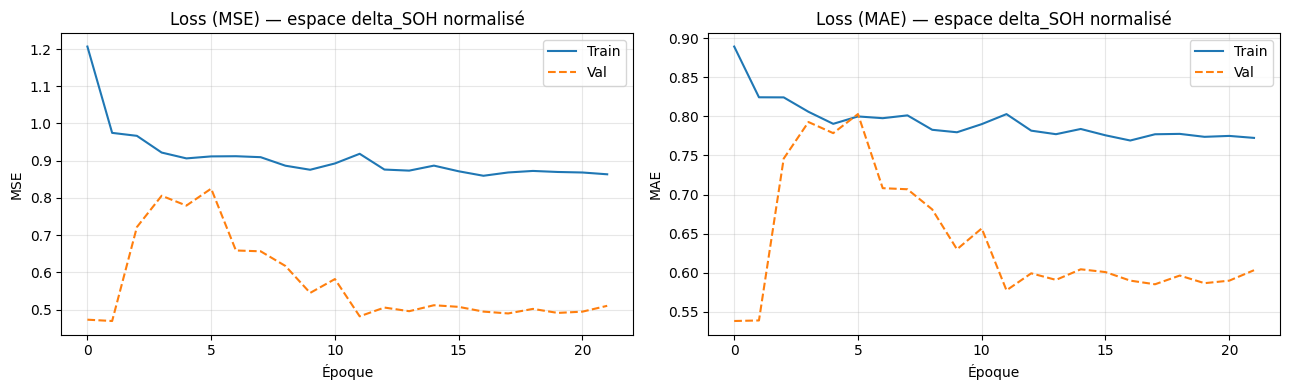

✅ loss_curves.png sauvegardé


In [ ]:
# ── 11.1  Courbes de perte ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history['loss'],     label='Train', linewidth=1.5)
axes[0].plot(history.history['val_loss'], label='Val',   linewidth=1.5, linestyle='--')
axes[0].set(xlabel='Époque', ylabel='MSE', title='Loss (MSE) — espace delta_SOH normalisé')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['mae'],     label='Train', linewidth=1.5)
axes[1].plot(history.history['val_mae'], label='Val',   linewidth=1.5, linestyle='--')
axes[1].set(xlabel='Époque', ylabel='MAE', title='Loss (MAE) — espace delta_SOH normalisé')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'loss_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ loss_curves.png sauvegardé')

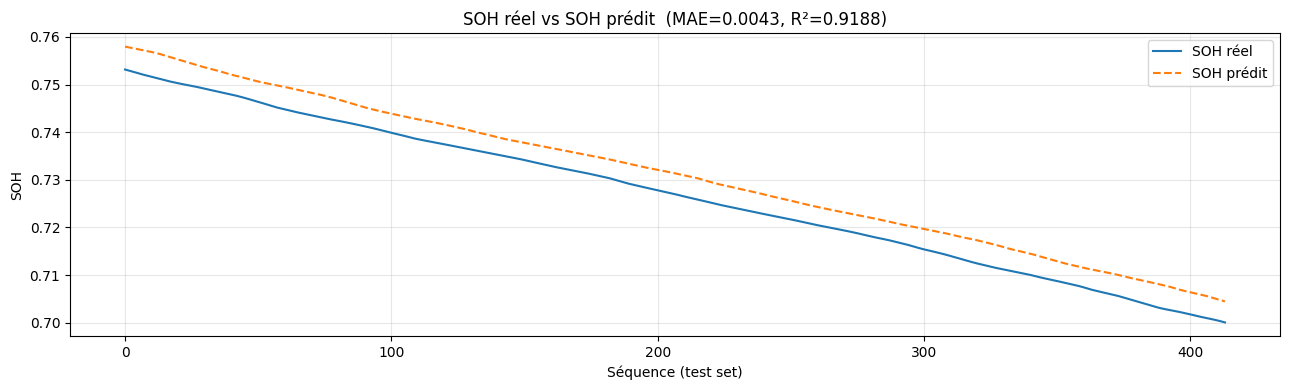

✅ soh_pred_vs_true.png sauvegardé


In [ ]:
# ── 11.2  SOH réel vs SOH prédit (série temporelle) ─────────────────────────
n_show = min(500, len(soh_pred))

plt.figure(figsize=(13, 4))
plt.plot(soh_true[:n_show], label='SOH réel',  linewidth=1.5)
plt.plot(soh_pred[:n_show], label='SOH prédit', linewidth=1.5, linestyle='--')
plt.xlabel('Séquence (test set)')
plt.ylabel('SOH')
plt.title(f'SOH réel vs SOH prédit  (MAE={mae:.4f}, R²={r2:.4f})')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'soh_pred_vs_true.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ soh_pred_vs_true.png sauvegardé')

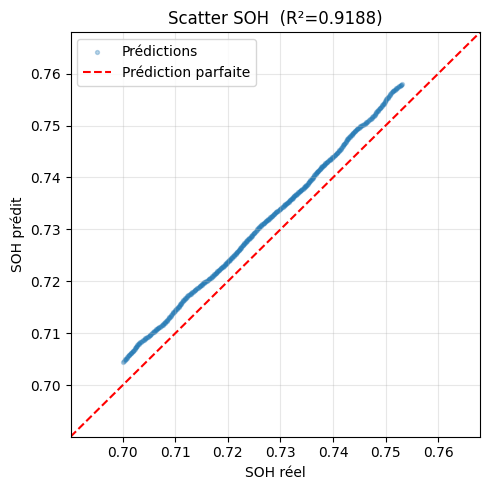

✅ scatter_soh.png sauvegardé


In [ ]:
# ── 11.3  Scatter : SOH réel vs SOH prédit ───────────────────────────────────
plt.figure(figsize=(5, 5))
plt.scatter(soh_true, soh_pred, alpha=0.3, s=8, label='Prédictions')

lims = [
    min(soh_true.min(), soh_pred.min()) - 0.01,
    max(soh_true.max(), soh_pred.max()) + 0.01
]
plt.plot(lims, lims, 'r--', linewidth=1.5, label='Prédiction parfaite')
plt.xlim(lims); plt.ylim(lims)
plt.xlabel('SOH réel')
plt.ylabel('SOH prédit')
plt.title(f'Scatter SOH  (R²={r2:.4f})')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'scatter_soh.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ scatter_soh.png sauvegardé')

In [ ]:
import joblib

# Modèle Keras
model_path = os.path.join(OUTPUT_DIR, 'lstm_soh_estimator.h5')
model.save(model_path)
print(f'✅ Modèle sauvegardé     → {model_path}')

# Scaler de la cible (nécessaire pour l'inférence)
scaler_path = os.path.join(OUTPUT_DIR, 'scaler_y.pkl')
joblib.dump(scaler_y, scaler_path)
print(f'✅ scaler_y sauvegardé   → {scaler_path}')

# Métriques
metrics_dict = {
    'MAE': mae, 'MSE': mse, 'RMSE': rmse,
    'MAPE': mape, 'SMAPE': smape,
    'MedianAE': medae, 'MaxError': me,
    'R2': r2, 'ExplainedVariance': evs
}
metrics_df = pd.DataFrame([metrics_dict])
metrics_path = os.path.join(OUTPUT_DIR, 'metrics.csv')
metrics_df.to_csv(metrics_path, index=False)
print(f'✅ Métriques sauvegardées → {metrics_path}')

print(f'\nContenu de {OUTPUT_DIR}/')
for f in sorted(os.listdir(OUTPUT_DIR)):
    print(f'  {f}')